# Sistem Rekomendasi Dosen Pembimbing Skripsi
### Berbasis NLP Menggunakan TF-IDF, Cosine Similarity, dan Sentence-BERT
**Program Studi Teknik Informatika - Universitas Lampung**

---
**Disusun oleh:**


*   Muhamad Hibban Ramadhan (2315061094)
*   M. Sidiq Firdaus (23150610)
*   Pangihutan Syahputra Purba (23150610)



**Alur Notebook:**
1. Instalasi Library
2. Import Library
3. Upload dan Load Data
4. Data Cleaning
5. Text Preprocessing
6. Pembuatan Profil Dosen
7. Metode 1 - TF-IDF + Cosine Similarity (Baseline)
8. Metode 2 - IndoBERT Sentence-BERT (Utama)
9. Evaluasi Top-K Accuracy
10. Perbandingan Hasil Kedua Metode
11. Demo Sistem Rekomendasi

---
## 1. Instalasi Library

In [1]:
!pip install PySastrawi sentence-transformers scikit-learn pandas numpy matplotlib seaborn tqdm -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.6/210.6 kB 3.7 MB/s eta 0:00:00


---
## 2. Import Library

In [2]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from tqdm import tqdm
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 80)
pd.set_option('display.max_columns', 20)

print('Semua library berhasil diimport.')

Semua library berhasil diimport.


---
## 3. Upload dan Load Data

Jalankan dua cell berikut secara bergantian untuk mengupload file dari laptop Anda.

In [3]:
# Upload file data usulan skripsi
from google.colab import files

print('Silakan upload file: data_usulan_skripsi_2026-05-07.csv')
uploaded_skripsi = files.upload()

Silakan upload file: data_usulan_skripsi_2026-05-07.csv


Saving data_usulan_skripsi_2026-05-07.csv to data_usulan_skripsi_2026-05-07.csv


In [4]:
# Upload file dataset publikasi dosen
print('Silakan upload file: dataset_publikasi_dosen_unila_final.csv')
uploaded_dosen = files.upload()

Silakan upload file: dataset_publikasi_dosen_unila_final.csv


Saving dataset_publikasi_dosen_unila_final.csv to dataset_publikasi_dosen_unila_final.csv


In [5]:
# Load kedua file ke dataframe
df_skripsi = pd.read_csv('data_usulan_skripsi_2026-05-07.csv')
df_dosen   = pd.read_csv('dataset_publikasi_dosen_unila_final.csv')

print('--- Data Usulan Skripsi ---')
print(f'Jumlah baris  : {len(df_skripsi)}')
print(f'Jumlah kolom  : {len(df_skripsi.columns)}')
print(f'Kolom         : {df_skripsi.columns.tolist()}')
print()
print('--- Dataset Publikasi Dosen ---')
print(f'Jumlah baris  : {len(df_dosen)}')
print(f'Jumlah kolom  : {len(df_dosen.columns)}')
print(f'Kolom         : {df_dosen.columns.tolist()}')
print(f'Jumlah dosen  : {df_dosen["Nama_Dosen"].nunique()}')

--- Data Usulan Skripsi ---
Jumlah baris  : 277
Jumlah kolom  : 11
Kolom         : ['NPM', 'Nama Mahasiswa', 'Tahun Masuk', 'Judul Penelitian', 'Topik Penelitian', 'Dosen Pembimbing', 'IPK Terakhir', 'Status KKN', 'Status PKL', 'Status Usulan', 'Tanggal Pengajuan']

--- Dataset Publikasi Dosen ---
Jumlah baris  : 1176
Jumlah kolom  : 4
Kolom         : ['Nama_Dosen', 'Keahlian_Dasar', 'Judul_Publikasi', 'Tahun_Publikasi']
Jumlah dosen  : 15


---
## 4. Data Cleaning

### 4.1 Normalisasi Nama Dosen

Terdapat inkonsistensi penulisan nama dosen antara kolom `Dosen Pembimbing` di data skripsi
dan kolom `Nama_Dosen` di data publikasi. Perbedaan ini disebabkan oleh variasi penulisan gelar
dan tanda baca. Normalisasi dilakukan agar kedua dataset dapat dicocokkan secara tepat.

In [6]:
# Mapping nama: dari penulisan di data skripsi ke penulisan standar di data publikasi
nama_mapping = {
    'Dr. Eng. Ir. Mardiana, S.T., M.T., IPM.' : 'Dr. Eng. Ir. Mardiana, M.T., IPM',
    'Ir. Gigih Forda Nama, S.T., M.T.I, IPM.' : 'Ir. Gigih Forda Nama, S.T., M.T.I., IPM',
    'Ir. Ing. Hery Dian Septama, S.T., IPM.'  : 'Ir. Ing. Hery Dian Septama, S.T., IPM',
    'Ir. Meizano Ardhi Muhammad, S.T., M.T., IPM.' : 'Ir. Meizano Ardhi Muhammad, S.T., M.T., IPM',
    'Ir. Trisya Septiana, ST.,MT., IPM.'       : 'Ir. Trisya Septiana, S.T., M.T., IPM',
    'Puput Budi Wintoro, S. Kom, M.T.I'        : 'Puput Budi Wintoro, S.Kom., M.T.I.',
    'Rio Ariestia Pradipta, S.Kom.,M.T.I.'     : 'Rio Ariestia Pradipta, S.Kom., M.T.I.',
}

df_skripsi['Dosen Pembimbing'] = df_skripsi['Dosen Pembimbing'].replace(nama_mapping)

# Verifikasi
dosen_skripsi   = set(df_skripsi['Dosen Pembimbing'].unique())
dosen_publikasi = set(df_dosen['Nama_Dosen'].unique())
tidak_cocok     = dosen_skripsi - dosen_publikasi

if tidak_cocok:
    print('Nama yang masih tidak cocok:')
    for d in sorted(tidak_cocok):
        print(f'  {d}')
else:
    print('Normalisasi selesai. Semua nama dosen sudah cocok antar dataset.')

print()
print('Distribusi dosen pembimbing di data skripsi setelah normalisasi:')
print(df_skripsi['Dosen Pembimbing'].value_counts().to_string())

Normalisasi selesai. Semua nama dosen sudah cocok antar dataset.

Distribusi dosen pembimbing di data skripsi setelah normalisasi:
Dosen Pembimbing
Dr. Eng. Ir. Mardiana, M.T., IPM               35
Dr. Ir. M. Komarudin, M.T.                     34
Ir. Gigih Forda Nama, S.T., M.T.I., IPM        32
Mahendra Pratama, S.T., M.Eng.                 28
Yessi Mulyani, M.T.                            27
Wahyu Eko Sulistiono, M.Sc.                    25
Ir. Trisya Septiana, S.T., M.T., IPM           22
Puput Budi Wintoro, S.Kom., M.T.I.             19
Ir. Titin Yulianti, S.T., M.Eng.               13
Ir. Resty Annisa, S.ST., M.Kom.                12
Rio Ariestia Pradipta, S.Kom., M.T.I.          12
Mona Arif Muda, M.T.                           10
Ir. Ing. Hery Dian Septama, S.T., IPM           5
Ir. Meizano Ardhi Muhammad, S.T., M.T., IPM     3


### 4.2 Standarisasi Topik Penelitian

Kolom `Topik Penelitian` memiliki nilai yang tidak konsisten, misalnya `RPL`, `Rekayasa Perangkat Lunak`,
dan `rekayasa perangkat lunak` merujuk pada topik yang sama. Standarisasi dilakukan menggunakan
pendekatan berbasis kata kunci (keyword matching).

In [7]:
def standardize_topic(topik):
    if not isinstance(topik, str):
        return 'Lainnya'
    t = topik.lower().strip()
    if any(k in t for k in ['machine learning', 'ml']):
        return 'Machine Learning'
    if any(k in t for k in ['deep learning']):
        return 'Deep Learning'
    if any(k in t for k in ['computer vision', 'pengolahan citra', 'image processing', 'citra']):
        return 'Computer Vision'
    if any(k in t for k in ['natural language', 'nlp', 'text mining']):
        return 'Natural Language Processing'
    if any(k in t for k in ['artificial intelligence', 'ai', 'sistem pakar', 'kecerdasan buatan']):
        return 'Artificial Intelligence'
    if any(k in t for k in ['rekayasa perangkat lunak', 'rpl', 'software engineering',
                             'pengembangan sistem', 'pengembangan aplikasi']):
        return 'Rekayasa Perangkat Lunak'
    if any(k in t for k in ['web', 'website', 'full-stack', 'frontend', 'backend']):
        return 'Web Development'
    if any(k in t for k in ['mobile', 'android', 'ios', 'flutter', 'react native']):
        return 'Mobile Development'
    if any(k in t for k in ['jaringan', 'networking', 'network']):
        return 'Jaringan Komputer'
    if any(k in t for k in ['iot', 'internet of things', 'embedded', 'mikrokontroler',
                             'smart farming', 'smart']):
        return 'IoT & Embedded System'
    if any(k in t for k in ['keamanan', 'security', 'cyber', 'kriptografi']):
        return 'Keamanan Sistem'
    if any(k in t for k in ['data mining', 'data science', 'big data', 'analitik']):
        return 'Data Mining & Science'
    if any(k in t for k in ['sistem informasi', 'enterprise']):
        return 'Sistem Informasi'
    if any(k in t for k in ['ui', 'ux', 'ui/ux', 'user experience', 'user interface']):
        return 'UI/UX'
    if any(k in t for k in ['cloud', 'devops', 'docker', 'kubernetes']):
        return 'Cloud & DevOps'
    if any(k in t for k in ['robotika', 'robotics', 'robot']):
        return 'Robotika'
    if any(k in t for k in ['database', 'basis data', 'dbms']):
        return 'Database'
    if t in ['ti', 'teknologi informasi', 'informatika']:
        return 'Teknologi Informasi (Umum)'
    return 'Lainnya'

df_skripsi['Topik_Asli']       = df_skripsi['Topik Penelitian']
df_skripsi['Topik Penelitian'] = df_skripsi['Topik Penelitian'].apply(standardize_topic)

print('Distribusi topik penelitian setelah standarisasi:')
print(df_skripsi['Topik Penelitian'].value_counts().to_string())

print()
lainnya = df_skripsi[df_skripsi['Topik Penelitian'] == 'Lainnya'][['Nama Mahasiswa', 'Topik_Asli']]
if lainnya.empty:
    print('Tidak ada data yang masuk kategori Lainnya.')
else:
    print(f'Data yang masuk kategori Lainnya ({len(lainnya)} baris) - perlu review manual:')
    print(lainnya.to_string())

Distribusi topik penelitian setelah standarisasi:
Topik Penelitian
Rekayasa Perangkat Lunak       99
Teknologi Informasi (Umum)     39
Artificial Intelligence        29
Lainnya                        19
IoT & Embedded System          16
Web Development                15
UI/UX                          14
Machine Learning               11
Computer Vision                 7
Mobile Development              6
Jaringan Komputer               6
Deep Learning                   5
Sistem Informasi                3
Cloud & DevOps                  2
Natural Language Processing     2
Keamanan Sistem                 2
Database                        2

Data yang masuk kategori Lainnya (19 baris) - perlu review manual:
                                    Nama Mahasiswa                        Topik_Asli
4                                    LAURA MAYLANI                   Deteksi Anomali
30                                       NUR AINUN           Rekayasa Perankat Lunak
46                             R

---
## 5. Text Preprocessing

Proses preprocessing teks mencakup:
- **Lowercasing**: mengubah seluruh teks menjadi huruf kecil
- **Cleaning**: menghapus karakter khusus, angka, dan tanda baca
- **Stopword Removal**: menghapus kata-kata umum bahasa Indonesia menggunakan PySastrawi
- **Stemming**: memotong imbuhan untuk mendapatkan kata dasar menggunakan PySastrawi

In [8]:
# Inisialisasi stemmer dan stopword remover
stemmer_factory        = StemmerFactory()
stemmer                = stemmer_factory.create_stemmer()

stopword_factory       = StopWordRemoverFactory()
stopword_remover       = stopword_factory.create_stop_word_remover()

def preprocess_text(text):
    """Melakukan preprocessing teks bahasa Indonesia."""
    if not isinstance(text, str) or text.strip() == '':
        return ''
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    text = stopword_remover.remove(text)
    text = stemmer.stem(text)
    return text

# Uji preprocessing
contoh = [
    'Penerapan Arsitektur ConvNeXt untuk Deteksi Dini Tuberkolosis pada Citra X-ray Dada',
    'Rancang Bangun Sistem Informasi Manajemen Aset Berbasis Web Menggunakan Framework Laravel',
    'Klasifikasi Penyakit Tanaman Padi Menggunakan Convolutional Neural Network'
]

print('Contoh hasil preprocessing:')
print(f'{"Teks Asli":<70} | {"Hasil Preprocessing"}')
print('-' * 120)
for c in contoh:
    print(f'{c:<70} | {preprocess_text(c)}')

Contoh hasil preprocessing:
Teks Asli                                                              | Hasil Preprocessing
------------------------------------------------------------------------------------------------------------------------
Penerapan Arsitektur ConvNeXt untuk Deteksi Dini Tuberkolosis pada Citra X-ray Dada | terap arsitektur convnext deteksi tuberkolosis citra ray dada
Rancang Bangun Sistem Informasi Manajemen Aset Berbasis Web Menggunakan Framework Laravel | rancang bangun sistem informasi manajemen aset bas web framework laravel
Klasifikasi Penyakit Tanaman Padi Menggunakan Convolutional Neural Network | klasifikasi sakit tanam padi convolutional neural network


In [9]:
# Terapkan preprocessing ke kolom Judul Penelitian
print('Preprocessing judul skripsi mahasiswa...')
df_skripsi['judul_clean'] = [
    preprocess_text(t) for t in tqdm(df_skripsi['Judul Penelitian'], desc='Skripsi')
]

# Terapkan preprocessing ke kolom Judul Publikasi dosen
print('Preprocessing judul publikasi dosen...')
df_dosen['judul_clean'] = [
    preprocess_text(t) for t in tqdm(df_dosen['Judul_Publikasi'], desc='Publikasi')
]

print()
print('Contoh hasil preprocessing data skripsi:')
print(df_skripsi[['Judul Penelitian', 'judul_clean']].head(4).to_string())

Preprocessing judul skripsi mahasiswa...


Skripsi: 100%|██████████| 277/277 [00:00<00:00, 2191.76it/s]


Preprocessing judul publikasi dosen...


Publikasi: 100%|██████████| 1176/1176 [00:00<00:00, 3079.34it/s]


Contoh hasil preprocessing data skripsi:
                                                                                                                           Judul Penelitian                                                                                             judul_clean
0  Pembangunan Website Relawan Trefa+ berbasis Laravel menggunakan Metode Iterative-Incremental (Studi Kasus: Kanwil DJPb Provinsi Lampung)  bangun website rawan trefa bas laravel metode iterative incremental studi kanwil djpb provinsi lampung
1                                                       Penerapan Arsitektur ConvNeXt untuk Deteksi Dini Tuberkolosis pada Citra X-ray Dada                                           terap arsitektur convnext deteksi tuberkolosis citra ray dada
2                                                                                                                          Web pembelajaran                                                                                       

---
## 6. Pembuatan Profil Dosen

Profil setiap dosen dibangun dengan menggabungkan (konkatenasi) seluruh judul publikasi
yang telah dipreprocess ditambah teks keahlian dasar yang sudah dipreprocess.
Hasilnya adalah satu dokumen representatif per dosen.

In [10]:
# Preprocessing keahlian dasar
df_dosen['keahlian_clean'] = [
    preprocess_text(t) for t in df_dosen['Keahlian_Dasar']
]

# Gabungkan seluruh judul publikasi + keahlian per dosen
dosen_profiles = (
    df_dosen
    .groupby('Nama_Dosen')
    .apply(lambda x: ' '.join(x['judul_clean'].tolist()) + ' ' + x['keahlian_clean'].iloc[0])
    .reset_index()
)
dosen_profiles.columns = ['Nama_Dosen', 'profile_text']

# Tambahkan keahlian asli untuk keperluan display
keahlian_asli = df_dosen[['Nama_Dosen', 'Keahlian_Dasar']].drop_duplicates()
dosen_profiles = dosen_profiles.merge(keahlian_asli, on='Nama_Dosen')

# Tambahkan jumlah publikasi per dosen
jml_publikasi  = df_dosen.groupby('Nama_Dosen').size().reset_index(name='Jumlah_Publikasi')
dosen_profiles = dosen_profiles.merge(jml_publikasi, on='Nama_Dosen')

print(f'Jumlah dosen dalam profil: {len(dosen_profiles)}')
print()
print(dosen_profiles[['Nama_Dosen', 'Keahlian_Dasar', 'Jumlah_Publikasi']].to_string())

Jumlah dosen dalam profil: 16

                                     Nama_Dosen                                                                                                                              Keahlian_Dasar  Jumlah_Publikasi
0              Dr. Eng. Ir. Mardiana, M.T., IPM                                                             Rekayasa Perangkat Lunak, Sistem Informasi, Teknologi Informasi, Tata Kelola TI                34
1                    Dr. Ir. M. Komarudin, M.T.                                   Teknologi IC, Entrepreneurship, Tata Kelola TI, Computer Vision, Sistem Pakar, Sistem Penunjang Keputusan               168
2       Ir. Gigih Forda Nama, S.T., M.T.I., IPM  Computer Networking, Internet of Things, Data Mining, Cloud Computing, SOA, Teknologi Informasi, Enterprise Architecture, Manajemen Risiko               217
3         Ir. Ing. Hery Dian Septama, S.T., IPM                                                           Rekayasa Perangkat Lunak, Sistem Inform

---
## 7. Metode 1 - TF-IDF + Cosine Similarity (Baseline)

Pendekatan klasik berbasis statistik. TF-IDF mengubah teks profil dosen dan judul skripsi
menjadi vektor numerik, kemudian kemiripan dihitung menggunakan Cosine Similarity.

In [11]:
# Bangun matriks TF-IDF dari profil dosen
tfidf_vectorizer  = TfidfVectorizer(ngram_range=(1, 2), min_df=1)
dosen_tfidf_matrix = tfidf_vectorizer.fit_transform(dosen_profiles['profile_text'])

print(f'Dimensi matriks TF-IDF dosen: {dosen_tfidf_matrix.shape}')
print(f'  Jumlah dosen   : {dosen_tfidf_matrix.shape[0]}')
print(f'  Jumlah fitur   : {dosen_tfidf_matrix.shape[1]}')

def recommend_tfidf(judul_mahasiswa, top_k=5):
    """Mengembalikan top-K rekomendasi dosen menggunakan TF-IDF + Cosine Similarity."""
    judul_clean  = preprocess_text(judul_mahasiswa)
    query_vec    = tfidf_vectorizer.transform([judul_clean])
    similarities = cosine_similarity(query_vec, dosen_tfidf_matrix)[0]
    top_indices  = similarities.argsort()[::-1][:top_k]
    results = []
    for rank, idx in enumerate(top_indices, start=1):
        results.append({
            'Rank'           : rank,
            'Nama_Dosen'     : dosen_profiles.iloc[idx]['Nama_Dosen'],
            'Keahlian_Dasar' : dosen_profiles.iloc[idx]['Keahlian_Dasar'],
            'Similarity'     : round(float(similarities[idx]), 4)
        })
    return pd.DataFrame(results)

# Uji fungsi
judul_uji = 'Klasifikasi Penyakit Tanaman Padi Menggunakan Convolutional Neural Network'
print()
print(f'Judul uji : {judul_uji}')
print()
print(recommend_tfidf(judul_uji, top_k=5).to_string(index=False))

Dimensi matriks TF-IDF dosen: (16, 9736)
  Jumlah dosen   : 16
  Jumlah fitur   : 9736

Judul uji : Klasifikasi Penyakit Tanaman Padi Menggunakan Convolutional Neural Network

 Rank                            Nama_Dosen                                                                                                                             Keahlian_Dasar  Similarity
    1    Puput Budi Wintoro, S.Kom., M.T.I. 3D Modelling And Animation, Jaringan Saraf Tiruan, Machine Learning, Natural Language Processing, Cloud Computing, Artificial Intelligence      0.1130
    2 Rio Ariestia Pradipta, S.Kom., M.T.I.                                                 Kecerdasan Buatan, Machine Learning, Deep Learning, Teknologi Informasi, Jaringan Komputer      0.0915
    3                   Yessi Mulyani, M.T.                                                                                  Jaringan Saraf Tiruan, Entrepreneurship, Pengolahan Citra      0.0907
    4       Ir. Resty Annisa, S.ST., M.Kom. 

---
## 8. Metode 2 - IndoBERT Sentence-BERT (Metode Utama)

Pendekatan modern berbasis representasi vektor kontekstual menggunakan model
`firqaaa/indo-sentence-bert-base`, yaitu model Sentence-BERT yang telah di-fine-tune
pada korpus teks bahasa Indonesia untuk tugas sentence similarity.

In [12]:
# Load model IndoBERT Sentence-BERT
print('Mengunduh dan memuat model IndoBERT Sentence-BERT...')
print('(Proses ini membutuhkan beberapa menit pada percobaan pertama)')

model_sbert = SentenceTransformer('firqaaa/indo-sentence-bert-base')

print('Model berhasil dimuat.')
print(f'Dimensi embedding : {model_sbert.get_sentence_embedding_dimension()}')

Mengunduh dan memuat model IndoBERT Sentence-BERT...
(Proses ini membutuhkan beberapa menit pada percobaan pertama)


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/118 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model berhasil dimuat.
Dimensi embedding : 768


In [13]:
# Encode semua profil dosen menjadi vektor embedding
print('Encoding profil dosen...')
dosen_embeddings = model_sbert.encode(
    dosen_profiles['profile_text'].tolist(),
    batch_size=8,
    show_progress_bar=True,
    convert_to_numpy=True
)

print(f'Shape embedding dosen: {dosen_embeddings.shape}')

def recommend_sbert(judul_mahasiswa, top_k=5):
    """Mengembalikan top-K rekomendasi dosen menggunakan IndoBERT Sentence-BERT."""
    judul_clean     = preprocess_text(judul_mahasiswa)
    query_embedding = model_sbert.encode([judul_clean], convert_to_numpy=True)
    similarities    = cosine_similarity(query_embedding, dosen_embeddings)[0]
    top_indices     = similarities.argsort()[::-1][:top_k]
    results = []
    for rank, idx in enumerate(top_indices, start=1):
        results.append({
            'Rank'           : rank,
            'Nama_Dosen'     : dosen_profiles.iloc[idx]['Nama_Dosen'],
            'Keahlian_Dasar' : dosen_profiles.iloc[idx]['Keahlian_Dasar'],
            'Similarity'     : round(float(similarities[idx]), 4)
        })
    return pd.DataFrame(results)

# Uji fungsi
print()
print(f'Judul uji : {judul_uji}')
print()
print(recommend_sbert(judul_uji, top_k=5).to_string(index=False))

Encoding profil dosen...


Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Shape embedding dosen: (16, 768)

Judul uji : Klasifikasi Penyakit Tanaman Padi Menggunakan Convolutional Neural Network

 Rank                       Nama_Dosen                                                                                                            Keahlian_Dasar  Similarity
    1      Wahyu Eko Sulistiono, M.Sc. Sistem Basis Data, Komunikasi Data, Jaringan Komputer, Pemrograman Berorientasi Objek, Pemrograman Web, Augmented Reality      0.4798
    2  Ir. Resty Annisa, S.ST., M.Kom.                                                                  Data Communications and Networking, Cloud Computing, SDN      0.4732
    3              Yessi Mulyani, M.T.                                                                 Jaringan Saraf Tiruan, Entrepreneurship, Pengolahan Citra      0.4655
    4 Ir. Titin Yulianti, S.T., M.Eng.                  Image Processing, Data Mining, Machine Learning, Jaringan Saraf Tiruan, Computer Vision, Embedded System      0.4487
    5       R

---
## 9. Evaluasi Top-K Accuracy

Evaluasi dilakukan menggunakan ground truth dari kolom `Dosen Pembimbing` pada data skripsi.
Metrik yang digunakan adalah **Top-K Accuracy**, yaitu persentase kasus di mana dosen pembimbing
yang sebenarnya muncul dalam daftar Top-K rekomendasi sistem.

Data yang digunakan untuk evaluasi adalah seluruh data skripsi yang dosen pembimbingnya
terdapat dalam dataset publikasi dosen.

In [14]:
# Filter data evaluasi: hanya yang dosen pembimbingnya ada di profil dosen
dosen_valid = set(dosen_profiles['Nama_Dosen'].tolist())
df_eval     = df_skripsi[df_skripsi['Dosen Pembimbing'].isin(dosen_valid)].copy()
df_tidak_eval = df_skripsi[~df_skripsi['Dosen Pembimbing'].isin(dosen_valid)]

print(f'Total data skripsi          : {len(df_skripsi)}')
print(f'Data yang dapat dievaluasi  : {len(df_eval)}')
print(f'Data tidak dapat dievaluasi : {len(df_tidak_eval)}')

if len(df_tidak_eval) > 0:
    print()
    print('Data tidak dapat dievaluasi (dosen tidak ada di dataset publikasi):')
    print(df_tidak_eval[['Nama Mahasiswa', 'Dosen Pembimbing']].to_string())

Total data skripsi          : 277
Data yang dapat dievaluasi  : 277
Data tidak dapat dievaluasi : 0


In [15]:
# Fungsi evaluasi generik
def evaluate_model(recommend_func, df_eval, k_values=[1, 3, 5], nama_metode='Model'):
    """
    Menghitung Top-K Accuracy untuk sebuah fungsi rekomendasi.

    Parameters
    ----------
    recommend_func : callable  - fungsi rekomendasi (menerima judul dan top_k)
    df_eval        : DataFrame - data ground truth
    k_values       : list      - nilai K yang dievaluasi
    nama_metode    : str       - nama metode untuk display

    Returns
    -------
    dict berisi akurasi per nilai K
    """
    max_k   = max(k_values)
    results = {k: 0 for k in k_values}
    detail  = []

    for _, row in tqdm(df_eval.iterrows(), total=len(df_eval), desc=nama_metode):
        judul_input   = row['Judul Penelitian']
        dosen_aktual  = row['Dosen Pembimbing']

        rekomendasi   = recommend_func(judul_input, top_k=max_k)
        nama_rekomen  = rekomendasi['Nama_Dosen'].tolist()

        row_result = {
            'NPM'           : row['NPM'],
            'Nama Mahasiswa': row['Nama Mahasiswa'],
            'Judul Penelitian': judul_input,
            'Dosen Aktual'  : dosen_aktual,
        }

        for k in k_values:
            hit = dosen_aktual in nama_rekomen[:k]
            row_result[f'Hit@{k}'] = hit
            if hit:
                results[k] += 1

        detail.append(row_result)

    total    = len(df_eval)
    accuracy = {k: round(v / total * 100, 2) for k, v in results.items()}

    print(f'\nHasil Evaluasi - {nama_metode}')
    print(f'  Total data evaluasi : {total}')
    for k in k_values:
        print(f'  Top-{k} Accuracy     : {accuracy[k]:.2f}%  ({results[k]}/{total})')

    return accuracy, pd.DataFrame(detail)

print('Fungsi evaluasi siap digunakan.')

Fungsi evaluasi siap digunakan.


In [16]:
# Evaluasi Metode 1: TF-IDF + Cosine Similarity
print('Menjalankan evaluasi Metode 1: TF-IDF + Cosine Similarity...')
acc_tfidf, detail_tfidf = evaluate_model(
    recommend_func = recommend_tfidf,
    df_eval        = df_eval,
    k_values       = [1, 3, 5],
    nama_metode    = 'TF-IDF + Cosine Similarity'
)

Menjalankan evaluasi Metode 1: TF-IDF + Cosine Similarity...


TF-IDF + Cosine Similarity: 100%|██████████| 277/277 [00:00<00:00, 369.95it/s]


Hasil Evaluasi - TF-IDF + Cosine Similarity
  Total data evaluasi : 277
  Top-1 Accuracy     : 13.72%  (38/277)
  Top-3 Accuracy     : 29.96%  (83/277)
  Top-5 Accuracy     : 46.21%  (128/277)


In [17]:
# Evaluasi Metode 2: IndoBERT Sentence-BERT
print('Menjalankan evaluasi Metode 2: IndoBERT Sentence-BERT...')
acc_sbert, detail_sbert = evaluate_model(
    recommend_func = recommend_sbert,
    df_eval        = df_eval,
    k_values       = [1, 3, 5],
    nama_metode    = 'IndoBERT Sentence-BERT'
)

Menjalankan evaluasi Metode 2: IndoBERT Sentence-BERT...


IndoBERT Sentence-BERT: 100%|██████████| 277/277 [00:43<00:00,  6.31it/s]


Hasil Evaluasi - IndoBERT Sentence-BERT
  Total data evaluasi : 277
  Top-1 Accuracy     : 9.75%  (27/277)
  Top-3 Accuracy     : 25.99%  (72/277)
  Top-5 Accuracy     : 40.07%  (111/277)


---
## 10. Perbandingan Hasil Kedua Metode

In [18]:
# Tabel perbandingan akurasi
df_comparison = pd.DataFrame({
    'Metode'    : ['TF-IDF + Cosine Similarity', 'IndoBERT Sentence-BERT'],
    'Top-1 (%)' : [acc_tfidf[1], acc_sbert[1]],
    'Top-3 (%)' : [acc_tfidf[3], acc_sbert[3]],
    'Top-5 (%)' : [acc_tfidf[5], acc_sbert[5]],
})

print('Tabel Perbandingan Akurasi')
print('=' * 65)
print(df_comparison.to_string(index=False))
print('=' * 65)

Tabel Perbandingan Akurasi
                    Metode  Top-1 (%)  Top-3 (%)  Top-5 (%)
TF-IDF + Cosine Similarity      13.72      29.96      46.21
    IndoBERT Sentence-BERT       9.75      25.99      40.07


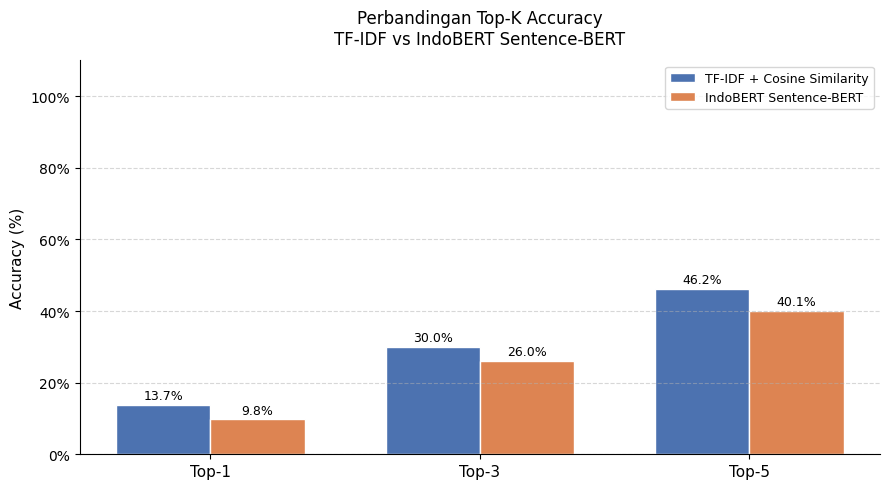

Grafik disimpan: perbandingan_akurasi.png


In [19]:
# Visualisasi 1: Grouped Bar Chart perbandingan akurasi
fig, ax = plt.subplots(figsize=(9, 5))

x         = np.arange(3)
width     = 0.35
labels_k  = ['Top-1', 'Top-3', 'Top-5']
vals_tfidf = [acc_tfidf[1], acc_tfidf[3], acc_tfidf[5]]
vals_sbert = [acc_sbert[1], acc_sbert[3], acc_sbert[5]]

bars1 = ax.bar(x - width/2, vals_tfidf, width, label='TF-IDF + Cosine Similarity',
               color='#4C72B0', edgecolor='white')
bars2 = ax.bar(x + width/2, vals_sbert, width, label='IndoBERT Sentence-BERT',
               color='#DD8452', edgecolor='white')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.8,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.8,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(labels_k, fontsize=11)
ax.set_ylabel('Accuracy (%)', fontsize=11)
ax.set_title('Perbandingan Top-K Accuracy\nTF-IDF vs IndoBERT Sentence-BERT', fontsize=12, pad=12)
ax.set_ylim(0, 110)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('perbandingan_akurasi.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafik disimpan: perbandingan_akurasi.png')

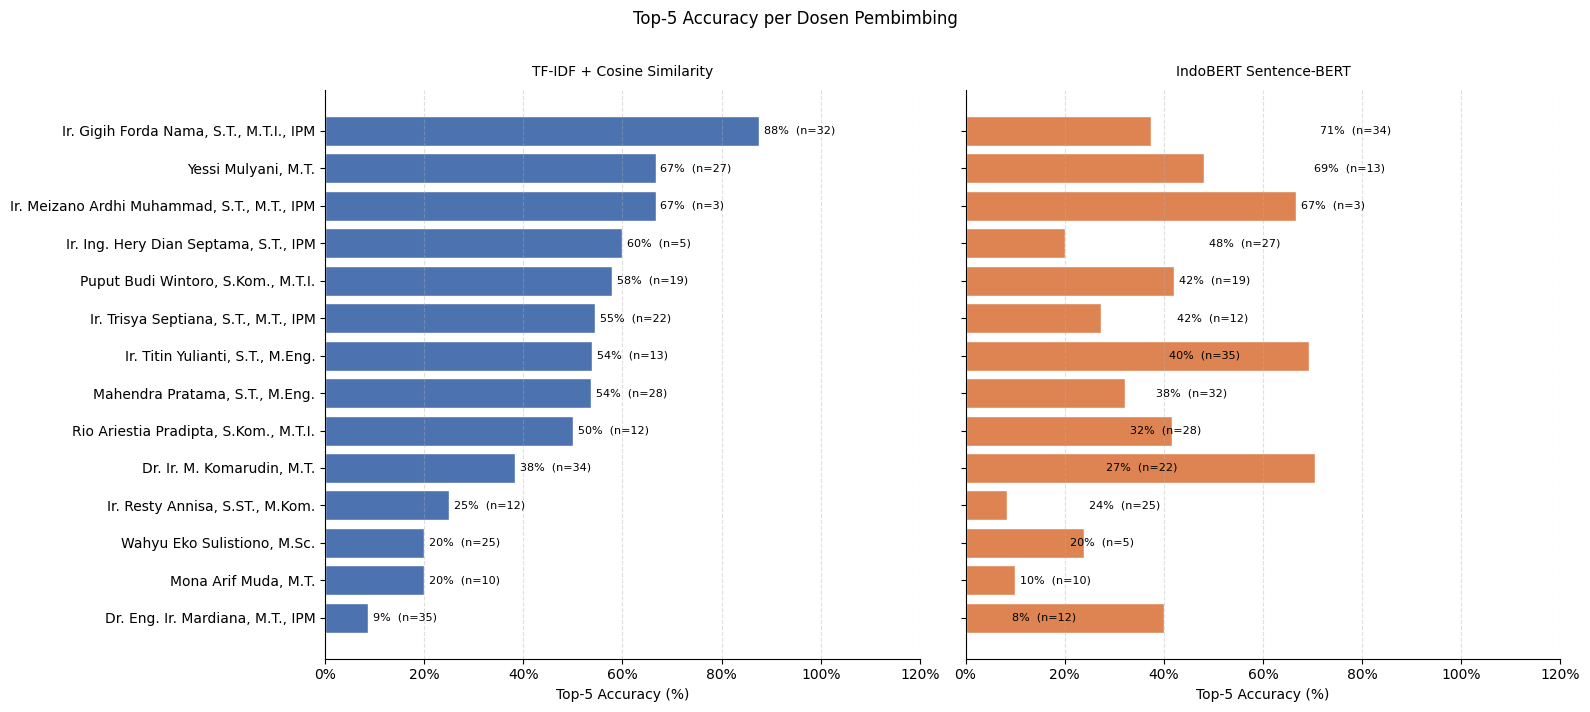

Grafik disimpan: akurasi_per_dosen.png


In [20]:
# Visualisasi 2: Akurasi per dosen pembimbing (Top-5)
def acc_per_dosen(detail_df, k=5):
    col   = f'Hit@{k}'
    grouped = detail_df.groupby('Dosen Aktual')[col].agg(['sum', 'count'])
    grouped['accuracy'] = grouped['sum'] / grouped['count'] * 100
    grouped = grouped.sort_values('accuracy', ascending=True)
    return grouped

fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)
titles    = ['TF-IDF + Cosine Similarity', 'IndoBERT Sentence-BERT']
details   = [detail_tfidf, detail_sbert]
colors    = ['#4C72B0', '#DD8452']

for ax, detail, title, color in zip(axes, details, titles, colors):
    grp = acc_per_dosen(detail, k=5)
    ax.barh(grp.index, grp['accuracy'], color=color, edgecolor='white')
    for i, (val, cnt) in enumerate(zip(grp['accuracy'], grp['count'])):
        ax.text(val + 1, i, f'{val:.0f}%  (n={cnt})', va='center', fontsize=8)
    ax.set_xlim(0, 120)
    ax.set_xlabel('Top-5 Accuracy (%)', fontsize=10)
    ax.set_title(title, fontsize=10, pad=10)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter())
    ax.grid(axis='x', linestyle='--', alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Top-5 Accuracy per Dosen Pembimbing', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('akurasi_per_dosen.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafik disimpan: akurasi_per_dosen.png')

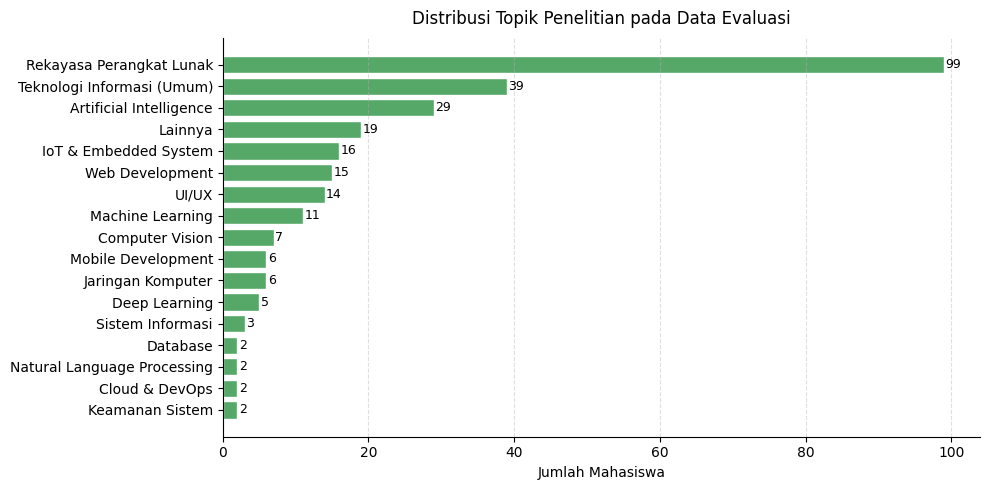

Grafik disimpan: distribusi_topik.png


In [21]:
# Visualisasi 3: Distribusi topik penelitian pada data evaluasi
fig, ax = plt.subplots(figsize=(10, 5))

topik_counts = df_eval['Topik Penelitian'].value_counts().sort_values(ascending=True)
ax.barh(topik_counts.index, topik_counts.values, color='#55A868', edgecolor='white')

for i, v in enumerate(topik_counts.values):
    ax.text(v + 0.2, i, str(v), va='center', fontsize=9)

ax.set_xlabel('Jumlah Mahasiswa', fontsize=10)
ax.set_title('Distribusi Topik Penelitian pada Data Evaluasi', fontsize=12, pad=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('distribusi_topik.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafik disimpan: distribusi_topik.png')

In [22]:
# Simpan detail hasil evaluasi ke CSV
detail_tfidf.to_csv('hasil_evaluasi_tfidf.csv', index=False)
detail_sbert.to_csv('hasil_evaluasi_sbert.csv', index=False)
df_comparison.to_csv('perbandingan_akurasi.csv', index=False)

print('Hasil evaluasi disimpan:')
print('  - hasil_evaluasi_tfidf.csv')
print('  - hasil_evaluasi_sbert.csv')
print('  - perbandingan_akurasi.csv')

Hasil evaluasi disimpan:
  - hasil_evaluasi_tfidf.csv
  - hasil_evaluasi_sbert.csv
  - perbandingan_akurasi.csv


---
## 10b. Metode 3 - Hybrid TF-IDF + IndoBERT

Pendekatan hybrid menggabungkan skor kemiripan dari TF-IDF dan IndoBERT
menggunakan weighted average. TF-IDF unggul dalam menangkap kecocokan
kata kunci spesifik, sementara IndoBERT unggul dalam kesamaan makna semantik.
Kombinasi keduanya diharapkan saling melengkapi kelemahan masing-masing.

Bobot yang diuji: alpha sebagai bobot TF-IDF, (1 - alpha) sebagai bobot IndoBERT.

In [23]:
def recommend_hybrid(judul_mahasiswa, top_k=5, alpha=0.6):
    """
    Mengembalikan top-K rekomendasi dosen menggunakan pendekatan hybrid.

    Parameters
    ----------
    judul_mahasiswa : str   - judul atau topik skripsi mahasiswa
    top_k           : int   - jumlah rekomendasi yang dikembalikan
    alpha           : float - bobot untuk skor TF-IDF (0.0 - 1.0)
                              bobot IndoBERT = 1 - alpha
    """
    judul_clean = preprocess_text(judul_mahasiswa)

    # Skor TF-IDF
    query_tfidf   = tfidf_vectorizer.transform([judul_clean])
    scores_tfidf  = cosine_similarity(query_tfidf, dosen_tfidf_matrix)[0]

    # Normalisasi skor TF-IDF ke rentang [0, 1]
    min_t, max_t  = scores_tfidf.min(), scores_tfidf.max()
    if max_t - min_t > 0:
        scores_tfidf_norm = (scores_tfidf - min_t) / (max_t - min_t)
    else:
        scores_tfidf_norm = scores_tfidf

    # Skor IndoBERT
    query_embed   = model_sbert.encode([judul_clean], convert_to_numpy=True)
    scores_sbert  = cosine_similarity(query_embed, dosen_embeddings)[0]

    # Normalisasi skor IndoBERT ke rentang [0, 1]
    min_s, max_s  = scores_sbert.min(), scores_sbert.max()
    if max_s - min_s > 0:
        scores_sbert_norm = (scores_sbert - min_s) / (max_s - min_s)
    else:
        scores_sbert_norm = scores_sbert

    # Gabungkan skor dengan bobot
    scores_hybrid = alpha * scores_tfidf_norm + (1 - alpha) * scores_sbert_norm

    top_indices   = scores_hybrid.argsort()[::-1][:top_k]
    results = []
    for rank, idx in enumerate(top_indices, start=1):
        results.append({
            'Rank'           : rank,
            'Nama_Dosen'     : dosen_profiles.iloc[idx]['Nama_Dosen'],
            'Keahlian_Dasar' : dosen_profiles.iloc[idx]['Keahlian_Dasar'],
            'Score_TFIDF'    : round(float(scores_tfidf[idx]), 4),
            'Score_SBERT'    : round(float(scores_sbert[idx]), 4),
            'Score_Hybrid'   : round(float(scores_hybrid[idx]), 4)
        })
    return pd.DataFrame(results)

# Uji fungsi dengan alpha default 0.6
print(f'Judul uji : {judul_uji}')
print()
print(recommend_hybrid(judul_uji, top_k=5, alpha=0.6).to_string(index=False))

Judul uji : Klasifikasi Penyakit Tanaman Padi Menggunakan Convolutional Neural Network

 Rank                            Nama_Dosen                                                                                                                             Keahlian_Dasar  Score_TFIDF  Score_SBERT  Score_Hybrid
    1       Ir. Resty Annisa, S.ST., M.Kom.                                                                                   Data Communications and Networking, Cloud Computing, SDN       0.0893       0.4732        0.8504
    2                   Yessi Mulyani, M.T.                                                                                  Jaringan Saraf Tiruan, Entrepreneurship, Pengolahan Citra       0.0907       0.4655        0.8369
    3    Puput Budi Wintoro, S.Kom., M.T.I. 3D Modelling And Animation, Jaringan Saraf Tiruan, Machine Learning, Natural Language Processing, Cloud Computing, Artificial Intelligence       0.1130       0.3933        0.7657
    4 Rio Ariestia P

In [24]:
# Uji berbagai nilai alpha untuk mencari kombinasi bobot optimal
alphas      = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
hasil_alpha = []

print('Mencari nilai alpha optimal...')
print(f'{"Alpha (TF-IDF)":<18} {"1-Alpha (SBERT)":<18} {"Top-1":<10} {"Top-3":<10} {"Top-5"}')
print('-' * 70)

for alpha in alphas:
    def recommend_hybrid_alpha(judul, top_k=5):
        return recommend_hybrid(judul, top_k=top_k, alpha=alpha)

    acc_temp = {}
    max_k    = 5
    hits     = {1: 0, 3: 0, 5: 0}

    for _, row in df_eval.iterrows():
        rek           = recommend_hybrid_alpha(row['Judul Penelitian'], top_k=max_k)
        nama_rek      = rek['Nama_Dosen'].tolist()
        dosen_aktual  = row['Dosen Pembimbing']
        for k in [1, 3, 5]:
            if dosen_aktual in nama_rek[:k]:
                hits[k] += 1

    total  = len(df_eval)
    top1   = round(hits[1] / total * 100, 2)
    top3   = round(hits[3] / total * 100, 2)
    top5   = round(hits[5] / total * 100, 2)

    hasil_alpha.append({'alpha': alpha, 'top1': top1, 'top3': top3, 'top5': top5})
    print(f'{alpha:<18.1f} {round(1-alpha, 1):<18.1f} {top1:<10} {top3:<10} {top5}')

df_alpha = pd.DataFrame(hasil_alpha)
best_alpha = df_alpha.loc[df_alpha['top5'].idxmax(), 'alpha']
print()
print(f'Alpha terbaik berdasarkan Top-5 Accuracy: {best_alpha}')

Mencari nilai alpha optimal...
Alpha (TF-IDF)     1-Alpha (SBERT)    Top-1      Top-3      Top-5
----------------------------------------------------------------------
0.3                0.7                10.47      31.05      44.4
0.4                0.6                13.72      31.05      44.77
0.5                0.5                13.72      29.24      44.4
0.6                0.4                13.72      29.6       44.4
0.7                0.3                14.44      31.41      44.04
0.8                0.2                12.64      29.24      43.68

Alpha terbaik berdasarkan Top-5 Accuracy: 0.4


In [25]:
# Evaluasi final hybrid menggunakan alpha terbaik
print(f'Menjalankan evaluasi Metode 3: Hybrid (alpha={best_alpha})...')

def recommend_hybrid_best(judul, top_k=5):
    return recommend_hybrid(judul, top_k=top_k, alpha=best_alpha)

acc_hybrid, detail_hybrid = evaluate_model(
    recommend_func = recommend_hybrid_best,
    df_eval        = df_eval,
    k_values       = [1, 3, 5],
    nama_metode    = f'Hybrid (alpha={best_alpha})'
)

Menjalankan evaluasi Metode 3: Hybrid (alpha=0.4)...


Hybrid (alpha=0.4): 100%|██████████| 277/277 [00:32<00:00,  8.48it/s]


Hasil Evaluasi - Hybrid (alpha=0.4)
  Total data evaluasi : 277
  Top-1 Accuracy     : 13.72%  (38/277)
  Top-3 Accuracy     : 31.05%  (86/277)
  Top-5 Accuracy     : 44.77%  (124/277)


In [26]:
# Perbarui tabel perbandingan dengan tiga metode
df_comparison_final = pd.DataFrame({
    'Metode'    : [
        'TF-IDF + Cosine Similarity',
        'IndoBERT Sentence-BERT',
        f'Hybrid TF-IDF + IndoBERT (alpha={best_alpha})'
    ],
    'Top-1 (%)' : [acc_tfidf[1],  acc_sbert[1],  acc_hybrid[1]],
    'Top-3 (%)' : [acc_tfidf[3],  acc_sbert[3],  acc_hybrid[3]],
    'Top-5 (%)' : [acc_tfidf[5],  acc_sbert[5],  acc_hybrid[5]],
})

print('Tabel Perbandingan Akurasi - Tiga Metode')
print('=' * 75)
print(df_comparison_final.to_string(index=False))
print('=' * 75)

Tabel Perbandingan Akurasi - Tiga Metode
                              Metode  Top-1 (%)  Top-3 (%)  Top-5 (%)
          TF-IDF + Cosine Similarity      13.72      29.96      46.21
              IndoBERT Sentence-BERT       9.75      25.99      40.07
Hybrid TF-IDF + IndoBERT (alpha=0.4)      13.72      31.05      44.77


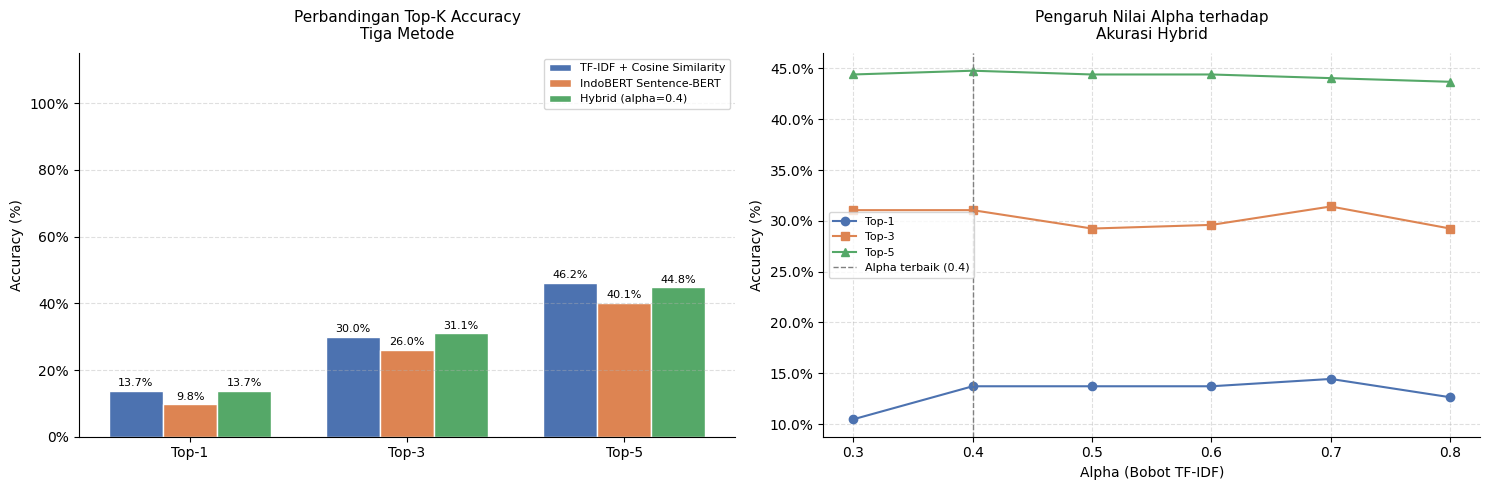

Grafik disimpan: perbandingan_tiga_metode.png


In [27]:
# Visualisasi grouped bar chart tiga metode
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# --- Chart kiri: grouped bar per nilai K ---
x      = np.arange(3)
width  = 0.25
labels_k = ['Top-1', 'Top-3', 'Top-5']

v_tfidf  = [acc_tfidf[1],  acc_tfidf[3],  acc_tfidf[5]]
v_sbert  = [acc_sbert[1],  acc_sbert[3],  acc_sbert[5]]
v_hybrid = [acc_hybrid[1], acc_hybrid[3], acc_hybrid[5]]

ax = axes[0]
b1 = ax.bar(x - width, v_tfidf,  width, label='TF-IDF + Cosine Similarity', color='#4C72B0', edgecolor='white')
b2 = ax.bar(x,         v_sbert,  width, label='IndoBERT Sentence-BERT',     color='#DD8452', edgecolor='white')
b3 = ax.bar(x + width, v_hybrid, width, label=f'Hybrid (alpha={best_alpha})', color='#55A868', edgecolor='white')

for bars in [b1, b2, b3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.8,
                f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(labels_k, fontsize=10)
ax.set_ylabel('Accuracy (%)', fontsize=10)
ax.set_title('Perbandingan Top-K Accuracy\nTiga Metode', fontsize=11, pad=10)
ax.set_ylim(0, 115)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(fontsize=8)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# --- Chart kanan: line chart pengaruh alpha ---
ax2 = axes[1]
ax2.plot(df_alpha['alpha'], df_alpha['top1'], marker='o', label='Top-1', color='#4C72B0')
ax2.plot(df_alpha['alpha'], df_alpha['top3'], marker='s', label='Top-3', color='#DD8452')
ax2.plot(df_alpha['alpha'], df_alpha['top5'], marker='^', label='Top-5', color='#55A868')
ax2.axvline(x=best_alpha, color='gray', linestyle='--', linewidth=1, label=f'Alpha terbaik ({best_alpha})')

ax2.set_xlabel('Alpha (Bobot TF-IDF)', fontsize=10)
ax2.set_ylabel('Accuracy (%)', fontsize=10)
ax2.set_title('Pengaruh Nilai Alpha terhadap\nAkurasi Hybrid', fontsize=11, pad=10)
ax2.yaxis.set_major_formatter(mtick.PercentFormatter())
ax2.legend(fontsize=8)
ax2.grid(linestyle='--', alpha=0.4)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('perbandingan_tiga_metode.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafik disimpan: perbandingan_tiga_metode.png')

In [28]:
# Simpan hasil evaluasi hybrid dan tabel perbandingan final
detail_hybrid.to_csv('hasil_evaluasi_hybrid.csv', index=False)
df_comparison_final.to_csv('perbandingan_akurasi_final.csv', index=False)

print('Hasil disimpan:')
print('  - hasil_evaluasi_hybrid.csv')
print('  - perbandingan_akurasi_final.csv')
print('  - perbandingan_tiga_metode.png')

Hasil disimpan:
  - hasil_evaluasi_hybrid.csv
  - perbandingan_akurasi_final.csv
  - perbandingan_tiga_metode.png


---
## 11. Demo Sistem Rekomendasi

Masukkan judul atau topik skripsi untuk mendapatkan rekomendasi dosen pembimbing
dari kedua metode sekaligus.

In [29]:
def demo_rekomendasi(judul_input, top_k=5):
    """
    Menampilkan rekomendasi dosen pembimbing dari ketiga metode
    untuk sebuah judul skripsi yang diinputkan.
    """
    print('=' * 80)
    print('SISTEM REKOMENDASI DOSEN PEMBIMBING SKRIPSI')
    print('Program Studi Teknik Informatika - Universitas Lampung')
    print('=' * 80)
    print(f'Judul/Topik             : {judul_input}')
    print(f'Jumlah rekomendasi (K)  : {top_k}')
    print()

    # Metode 1
    print('--- Metode 1: TF-IDF + Cosine Similarity ---')
    hasil_tfidf = recommend_tfidf(judul_input, top_k=top_k)
    print(hasil_tfidf[['Rank', 'Nama_Dosen', 'Similarity']].to_string(index=False))
    print()

    # Metode 2
    print('--- Metode 2: IndoBERT Sentence-BERT ---')
    hasil_sbert = recommend_sbert(judul_input, top_k=top_k)
    print(hasil_sbert[['Rank', 'Nama_Dosen', 'Similarity']].to_string(index=False))
    print()

    # Metode 3
    print(f'--- Metode 3: Hybrid TF-IDF + IndoBERT (alpha={best_alpha}) ---')
    hasil_hybrid = recommend_hybrid(judul_input, top_k=top_k, alpha=best_alpha)
    print(hasil_hybrid[['Rank', 'Nama_Dosen', 'Score_TFIDF', 'Score_SBERT', 'Score_Hybrid']].to_string(index=False))
    print('=' * 80)


# --- Ubah judul di bawah sesuai kebutuhan ---
judul_demo = 'Penerapan Deep Learning untuk Deteksi Objek pada Video Pengawasan'
demo_rekomendasi(judul_demo, top_k=5)

SISTEM REKOMENDASI DOSEN PEMBIMBING SKRIPSI
Program Studi Teknik Informatika - Universitas Lampung
Judul/Topik             : Penerapan Deep Learning untuk Deteksi Objek pada Video Pengawasan
Jumlah rekomendasi (K)  : 5

--- Metode 1: TF-IDF + Cosine Similarity ---
 Rank                            Nama_Dosen  Similarity
    1      Ir. Titin Yulianti, S.T., M.Eng.      0.0961
    2 Rio Ariestia Pradipta, S.Kom., M.T.I.      0.0476
    3           Wahyu Eko Sulistiono, M.Sc.      0.0346
    4    Puput Budi Wintoro, S.Kom., M.T.I.      0.0294
    5  Ir. Trisya Septiana, S.T., M.T., IPM      0.0209

--- Metode 2: IndoBERT Sentence-BERT ---
 Rank                                  Nama_Dosen  Similarity
    1       Ir. Ing. Hery Dian Septama, S.T., IPM      0.4855
    2                  Dr. Ir. M. Komarudin, M.T.      0.4820
    3 Ir. Meizano Ardhi Muhammad, S.T., M.T., IPM      0.4781
    4                        Mona Arif Muda, M.T.      0.4726
    5            Ir. Titin Yulianti, S.T., M.En

In [30]:
# Contoh demo kedua - topik berbeda
judul_demo2 = 'Rancang Bangun Sistem Informasi Manajemen Perpustakaan Berbasis Web'
demo_rekomendasi(judul_demo2, top_k=5)

SISTEM REKOMENDASI DOSEN PEMBIMBING SKRIPSI
Program Studi Teknik Informatika - Universitas Lampung
Judul/Topik             : Rancang Bangun Sistem Informasi Manajemen Perpustakaan Berbasis Web
Jumlah rekomendasi (K)  : 5

--- Metode 1: TF-IDF + Cosine Similarity ---
 Rank                                  Nama_Dosen  Similarity
    1 Ir. Meizano Ardhi Muhammad, S.T., M.T., IPM      0.2245
    2                  R. Arum Setia Priadi, M.T.      0.1877
    3     Ir. Gigih Forda Nama, S.T., M.T.I., IPM      0.1848
    4       Ir. Ing. Hery Dian Septama, S.T., IPM      0.1723
    5            Dr. Eng. Ir. Mardiana, M.T., IPM      0.1688

--- Metode 2: IndoBERT Sentence-BERT ---
 Rank                                  Nama_Dosen  Similarity
    1            Dr. Eng. Ir. Mardiana, M.T., IPM      0.6090
    2       Rio Ariestia Pradipta, S.Kom., M.T.I.      0.5997
    3 Ir. Meizano Ardhi Muhammad, S.T., M.T., IPM      0.5624
    4          Puput Budi Wintoro, S.Kom., M.T.I.      0.5548
    5    

In [31]:
# Contoh demo ketiga - topik berbeda
judul_demo3 = 'Implementasi Internet of Things untuk Monitoring Kualitas Udara di Dalam Ruangan'
demo_rekomendasi(judul_demo3, top_k=5)

SISTEM REKOMENDASI DOSEN PEMBIMBING SKRIPSI
Program Studi Teknik Informatika - Universitas Lampung
Judul/Topik             : Implementasi Internet of Things untuk Monitoring Kualitas Udara di Dalam Ruangan
Jumlah rekomendasi (K)  : 5

--- Metode 1: TF-IDF + Cosine Similarity ---
 Rank                              Nama_Dosen  Similarity
    1 Ir. Gigih Forda Nama, S.T., M.T.I., IPM      0.1319
    2              Dr. Ir. M. Komarudin, M.T.      0.0926
    3   Ir. Ing. Hery Dian Septama, S.T., IPM      0.0727
    4         Ir. Resty Annisa, S.ST., M.Kom.      0.0721
    5   Rio Ariestia Pradipta, S.Kom., M.T.I.      0.0693

--- Metode 2: IndoBERT Sentence-BERT ---
 Rank                                  Nama_Dosen  Similarity
    1     Ir. Gigih Forda Nama, S.T., M.T.I., IPM      0.4607
    2                 Wahyu Eko Sulistiono, M.Sc.      0.4498
    3 Ir. Meizano Ardhi Muhammad, S.T., M.T., IPM      0.4408
    4       Rio Ariestia Pradipta, S.Kom., M.T.I.      0.4355
    5            Ir.

In [32]:
# Save model

import os, json
import joblib
import numpy as np
import scipy.sparse

SAVE_DIR = "models"
os.makedirs(SAVE_DIR, exist_ok=True)

# 1. TF-IDF vectorizer
joblib.dump(tfidf_vectorizer, f"{SAVE_DIR}/tfidf_vectorizer.joblib")
print("✅ tfidf_vectorizer.joblib")

# 2. TF-IDF matrix (sparse)
scipy.sparse.save_npz(f"{SAVE_DIR}/dosen_tfidf_matrix.npz", dosen_tfidf_matrix)
print("✅ dosen_tfidf_matrix.npz")

# 3. SBERT embeddings (numpy array)
np.save(f"{SAVE_DIR}/dosen_embeddings.npy", dosen_embeddings)
print("✅ dosen_embeddings.npy")

# 4. Profil dosen (DataFrame)
dosen_profiles.to_csv(f"{SAVE_DIR}/dosen_profiles.csv", index=False)
print("✅ dosen_profiles.csv")

# 5. Model SBERT (agar tidak perlu download ulang saat deploy)
model_sbert.save(f"{SAVE_DIR}/indo_sbert_model")
print("✅ indo_sbert_model/")

# 6. best_alpha
config = {"best_alpha": float(best_alpha)}
with open(f"{SAVE_DIR}/config.json", "w") as f:
    json.dump(config, f)
print("✅ config.json")

print(f"\nSemua artefak tersimpan di folder '{SAVE_DIR}/'")
print("Isi folder:")
for root, dirs, files in os.walk(SAVE_DIR):
    level = root.replace(SAVE_DIR, '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')
    subindent = '  ' * (level + 1)
    for file in files:
        fpath = os.path.join(root, file)
        size_mb = os.path.getsize(fpath) / 1024 / 1024
        print(f'{subindent}{file}  ({size_mb:.1f} MB)')


✅ tfidf_vectorizer.joblib
✅ dosen_tfidf_matrix.npz
✅ dosen_embeddings.npy
✅ dosen_profiles.csv


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ indo_sbert_model/
✅ config.json

Semua artefak tersimpan di folder 'models/'
Isi folder:
models/
  dosen_tfidf_matrix.npz  (0.1 MB)
  config.json  (0.0 MB)
  dosen_embeddings.npy  (0.0 MB)
  dosen_profiles.csv  (0.1 MB)
  tfidf_vectorizer.joblib  (0.2 MB)
  indo_sbert_model/
    tokenizer_config.json  (0.0 MB)
    config_sentence_transformers.json  (0.0 MB)
    sentence_bert_config.json  (0.0 MB)
    config.json  (0.0 MB)
    README.md  (0.0 MB)
    model.safetensors  (474.7 MB)
    tokenizer.json  (0.7 MB)
    modules.json  (0.0 MB)
    1_Pooling/
      config.json  (0.0 MB)
